In [13]:
import pickle
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    classification_report,
    accuracy_score,
    f1_score,
    confusion_matrix,
    precision_score,
    recall_score,
    ConfusionMatrixDisplay
)

from xgboost import XGBClassifier

import mlflow

In [ ]:
mlflow.set_tracking_uri("http://localhost:5000")

print(mlflow.get_tracking_uri())

mlflow.set_experiment("Complaint Text Classification")

In [2]:
train = pd.read_parquet("../data/train.parquet")
val = pd.read_parquet("../data/val.parquet")
test = pd.read_parquet("../data/test.parquet")

text_col = "clean_complaint_text"

In [3]:
X_train = train[text_col]
y_train = train["Product"]

X_val = val[text_col]
y_val = val["Product"]

X_test = test[text_col]
y_test = test["Product"]

In [4]:
with open('../models/label_encoder.pkl', 'rb') as f:
    label_encoder = pickle.load(f)

with open('../models/xgb_pipeline.pkl', 'rb') as f:
    xgb_pipeline =pickle.load(f)

y_train_encoded = label_encoder.fit_transform(y_train)
y_val_encoded = label_encoder.transform(y_val)

In [5]:
val_predictions_xgb_encoded = xgb_pipeline.predict(X_val)

val_predictions_xgb = label_encoder.inverse_transform(
    val_predictions_xgb_encoded.astype(int)
)

error_df = pd.DataFrame({
    "text": X_val,
    "actual": label_encoder.inverse_transform(y_val_encoded),
    "predicted": val_predictions_xgb
})

error_df["correct"] = error_df["actual"] == error_df["predicted"]

misclassified = error_df[
    error_df["correct"] == False
].copy()

print("Total validation errors:", len(misclassified))

Total validation errors: 1251


In [6]:
confusion_pairs = (
    misclassified
    .groupby(["actual", "predicted"])
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
)

confusion_pairs.head(15)

,actual,predicted,count
3,Checking or savings account,"Money transfer, virtual currency, or money ser...",160
28,"Money transfer, virtual currency, or money ser...",Checking or savings account,153
7,Credit card,Checking or savings account,67
55,Vehicle loan or lease,"Payday loan, title loan, personal loan, or adv...",59
40,Mortgage,"Payday loan, title loan, personal loan, or adv...",50
45,"Payday loan, title loan, personal loan, or adv...",Debt collection,49
0,Checking or savings account,Credit card,49
48,"Payday loan, title loan, personal loan, or adv...",Vehicle loan or lease,48
23,Debt collection,Credit reporting or other personal consumer re...,41
44,"Payday loan, title loan, personal loan, or adv...",Credit reporting or other personal consumer re...,36


In [7]:
category_errors = (
    misclassified
    .groupby("actual")
    .size()
    .sort_values(ascending=False)
)

category_errors

actual
Checking or savings account                                250
Payday loan, title loan, personal loan, or advance loan    213
Money transfer, virtual currency, or money service         199
Credit card                                                176
Vehicle loan or lease                                      137
Debt collection                                            130
Mortgage                                                    76
Credit reporting or other personal consumer reports         70
dtype: int64

In [8]:
error_df["word_count"] = error_df["text"].str.split().str.len()
error_df["char_count"] = error_df["text"].str.len()
error_df.groupby(
    pd.cut(
        error_df["word_count"],
        bins=[0, 25, 50, 100, 200, 500, float("inf")]
    ),
    observed=True
).agg(
    total=("correct", "size"),
    errors=("correct", lambda x: (~x).sum())
)

,total,errors
word_count,,
"(0.0, 25.0]",286,89
"(25.0, 50.0]",537,136
"(50.0, 100.0]",1238,236
"(100.0, 200.0]",2251,345
"(200.0, 500.0]",2608,383
"(500.0, inf]",579,62


In [9]:
category_analysis = (
    error_df
    .groupby("actual")
    .agg(
        total=("correct", "size"),
        errors=("correct", lambda x: (~x).sum())
    )
)

category_analysis["error_rate_%"] = (
    category_analysis["errors"] /
    category_analysis["total"] * 100
)

category_analysis.sort_values(
    "error_rate_%",
    ascending=False
)

,total,errors,error_rate_%
actual,,,
Checking or savings account,938,250,26.652452
"Payday loan, title loan, personal loan, or advance loan",937,213,22.732124
"Money transfer, virtual currency, or money service",937,199,21.237994
Credit card,938,176,18.763326
Vehicle loan or lease,938,137,14.605544
Debt collection,937,130,13.874066
Mortgage,938,76,8.102345
Credit reporting or other personal consumer reports,937,70,7.470651


In [10]:
length_analysis = (
    error_df
    .groupby(
        pd.cut(
            error_df["word_count"],
            bins=[0, 25, 50, 100, 200, 500, float("inf")]
        ),
        observed=True
    )
    .agg(
        total=("correct", "size"),
        errors=("correct", lambda x: (~x).sum())
    )
)

length_analysis["error_rate_%"] = (
    length_analysis["errors"] /
    length_analysis["total"] * 100
)

length_analysis

,total,errors,error_rate_%
word_count,,,
"(0.0, 25.0]",286,89,31.118881
"(25.0, 50.0]",537,136,25.325885
"(50.0, 100.0]",1238,236,19.063005
"(100.0, 200.0]",2251,345,15.326522
"(200.0, 500.0]",2608,383,14.685583
"(500.0, inf]",579,62,10.708117


In [11]:
misclassified.to_csv(
    "../results/xgb_validation_errors.csv",
    index=False
)

In [12]:
confusion_pairs.to_csv(
    "../results/xgb_confusion_pairs.csv",
    index=False
)

In [14]:
test_predictions_xgb_encoded = xgb_pipeline.predict(X_test)
y_test_encoded = label_encoder.transform(y_test)

test_predictions_xgb = label_encoder.inverse_transform(
    test_predictions_xgb_encoded.astype(int)
)

test_accuracy = accuracy_score(
    y_test_encoded,
    test_predictions_xgb_encoded
)

test_precision = precision_score(
    y_test_encoded,
    test_predictions_xgb_encoded,
    average="weighted"
)

test_recall = recall_score(
    y_test_encoded,
    test_predictions_xgb_encoded,
    average="weighted"
)

test_macro_f1 = f1_score(
    y_test_encoded,
    test_predictions_xgb_encoded,
    average="macro"
)

test_weighted_f1 = f1_score(
    y_test_encoded,
    test_predictions_xgb_encoded,
    average="weighted"
)

print(f"Test Accuracy:       {test_accuracy:.4f}")
print(f"Test Precision:      {test_precision:.4f}")
print(f"Test Recall:         {test_recall:.4f}")
print(f"Test Macro F1:       {test_macro_f1:.4f}")
print(f"Test Weighted F1:    {test_weighted_f1:.4f}")
print(
    classification_report(
        y_test_encoded,
        test_predictions_xgb_encoded,
        target_names=label_encoder.classes_
    )
)

Test Accuracy:       0.8323
Test Precision:      0.8337
Test Recall:         0.8323
Test Macro F1:       0.8326
Test Weighted F1:    0.8326
                                                         precision    recall  f1-score   support

                            Checking or savings account       0.73      0.77      0.75       937
                                            Credit card       0.84      0.81      0.83       937
    Credit reporting or other personal consumer reports       0.84      0.92      0.88       938
                                        Debt collection       0.86      0.84      0.85       938
     Money transfer, virtual currency, or money service       0.78      0.78      0.78       938
                                               Mortgage       0.95      0.91      0.93       937
Payday loan, title loan, personal loan, or advance loan       0.77      0.77      0.77       938
                                  Vehicle loan or lease       0.89      0.87      0

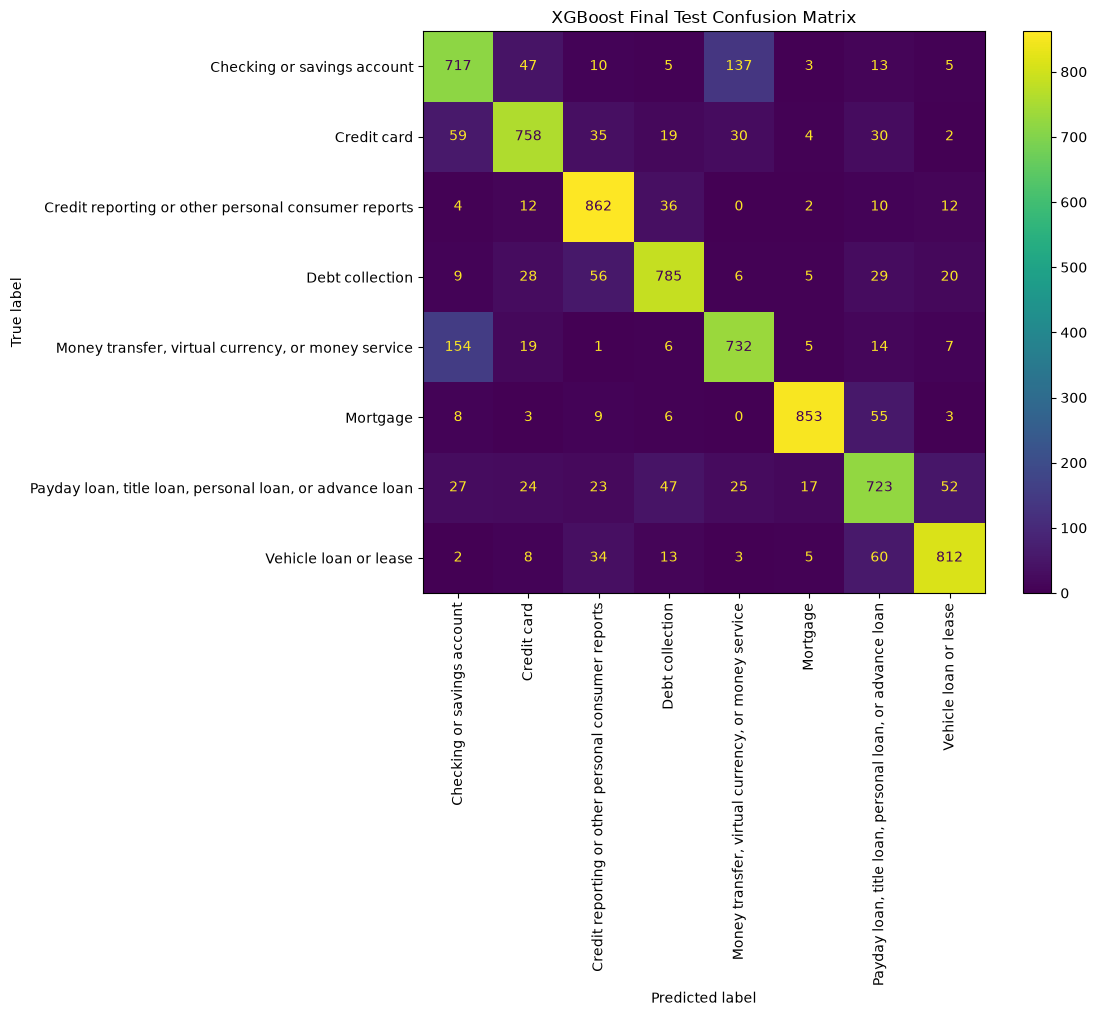

                                                         precision    recall  f1-score   support

                            Checking or savings account       0.73      0.77      0.75       937
                                            Credit card       0.84      0.81      0.83       937
    Credit reporting or other personal consumer reports       0.84      0.92      0.88       938
                                        Debt collection       0.86      0.84      0.85       938
     Money transfer, virtual currency, or money service       0.78      0.78      0.78       938
                                               Mortgage       0.95      0.91      0.93       937
Payday loan, title loan, personal loan, or advance loan       0.77      0.77      0.77       938
                                  Vehicle loan or lease       0.89      0.87      0.88       937

                                               accuracy                           0.83      7500
                            

In [15]:
from sklearn.metrics import ConfusionMatrixDisplay

cm_test = confusion_matrix(
    y_test_encoded,
    test_predictions_xgb_encoded
)

fig, ax = plt.subplots(figsize=(12, 10))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_test,
    display_labels=label_encoder.classes_
)

disp.plot(
    ax=ax,
    xticks_rotation=90
)

plt.title("XGBoost Final Test Confusion Matrix")
plt.tight_layout()

plt.savefig(
    "../results/confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

from sklearn.metrics import classification_report

report = classification_report(
    y_test_encoded,
    test_predictions_xgb_encoded,
    target_names=label_encoder.classes_
)

print(report)

with open(
    "../results/classification_report.txt",
    "w",
    encoding="utf-8"
) as f:
    f.write(report)

In [ ]:
with mlflow.start_run(run_name="xgboost-final"):

    # Parameters
    mlflow.log_param("model", "XGBoost")

    mlflow.log_param("n_estimators", 300)
    mlflow.log_param("max_depth", 6)
    mlflow.log_param("learning_rate", 0.1)

    mlflow.log_param("tfidf_max_features", 20000)
    mlflow.log_param("tfidf_ngram_range", "(1,2)")

    mlflow.log_param("dataset_size", 50000)
    mlflow.log_param("train_size", 35000)
    mlflow.log_param("validation_size", 7500)
    mlflow.log_param("test_size", 7500)

    # Final test metrics
    mlflow.log_metric("test_accuracy", 0.8323)
    mlflow.log_metric("test_precision", 0.8337)
    mlflow.log_metric("test_recall", 0.8323)
    mlflow.log_metric("test_macro_f1", 0.8326)
    mlflow.log_metric("test_weighted_f1", 0.8326)

    # Model artifacts
    mlflow.log_artifact(
        "../models/xgb_pipeline.pkl"
    )

    mlflow.log_artifact(
        "../models/label_encoder.pkl"
    )

    mlflow.log_artifact(
        "../models/tfidf_vectorizer.pkl"
    )

    # Evaluation artifacts
    mlflow.log_artifact(
        "../results/confusion_matrix.png"
    )

    mlflow.log_artifact(
        "../results/classification_report.txt"
    )

print("Final MLflow run logged.")